In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os
from coord_convert.transform import wgs2gcj,gcj2wgs
import requests
from bs4 import BeautifulSoup
import time

In [23]:
path = "../inputs/boundary"
for i in os.listdir(path):
    if i.endswith('.shp'):
        gdf = gpd.read_file(os.path.join(path, i))
        # gdf.plot()
# bounds = gdf.total_bounds 
# minx, miny, maxx, maxy = bounds
# polygon = f"{minx},{miny};{maxx},{maxy}"

# def convert_to_gcj(row):
#     # 提取几何中心点（或边界）
#     minx, miny, maxx, maxy = row.geometry.bounds
#     # 转换四个角点（简化：只转 min 和 max）
#     min_gcj = wgs2gcj(miny, minx)  # 注意：wgs2gcj(lat, lon)
#     max_gcj = wgs2gcj(maxy, maxx)

#     min_lon, min_lat = round(min_gcj[1], 6), round(min_gcj[0], 6)
#     max_lon, max_lat = round(max_gcj[1], 6), round(max_gcj[0], 6)
#     return f"{min_lon},{min_lat};{max_lon},{max_lat}"
def wgs_to_gcj(lon, lat):
    gcj_lon, gcj_lat = wgs2gcj(lon, lat)  # 注意：你已有 wgs2gcj 函数
    return gcj_lon, gcj_lat
# 假设你的原始多边形边界是 WGS84
gdf_wgs84 = gdf.to_crs(epsg=4326)
minx, miny, maxx, maxy = gdf_wgs84.total_bounds  # WGS84
# 转换边界（注意：矩形边界转换后可能不再是严格矩形，但可近似）
gcj_minx, gcj_miny = wgs_to_gcj(minx, miny)
gcj_maxx, gcj_maxy = wgs_to_gcj(maxx, maxy)

# 构造 GCJ-02 的 polygon 字符串
polygon_gcj = f"{gcj_minx},{gcj_miny}|{gcj_maxx},{gcj_maxy}"

In [24]:
# 你当前读取 shapefile 的代码：
gdf = gpd.read_file(os.path.join(path, i))
# 默认 CRS 很可能是 EPSG:4326 (WGS84)
print(gdf.crs)  # 检查是否为 WGS84

EPSG:4547


In [25]:
polygon_gcj

'112.96765376513916,27.979860576514387|113.03710717337279,28.027694328922166'

In [13]:
polygon_gcj

'112.980874,27.99902|113.0016,28.017005'

In [4]:
def extract_key_info(poi):
    """从单个 POI 中提取关键信息"""
    return {
        "id": poi.get("id", ""),
        "name": poi.get("name", ""),
        "type": poi.get("type", ""),
        "location": poi.get("location", ""),  # 格式: "lon,lat"
        "address": poi.get("address", ""),
        "tel": poi.get("tel", ""),
        "business_area": poi.get("business_area", "")
    }

def fetch_poi_in_polygon(polygon, api_key, keywords=None, types=None, offset=20):
    all_pois = []
    page = 1
    print(f"Fetching POIs in polygon: {polygon}")
    
    while True:
        params = {
            "key": api_key,
            "keywords": keywords or "",
            "types": types or "",
            "polygon": polygon,
            "offset": min(offset, 25),  # 高德最大 offset=25，但免费版建议≤20
            "page": page,
            "extensions": "all"
        }
        response = requests.get("https://restapi.amap.com/v3/place/polygon", params=params)
        data = response.json()
        
        if data["status"] == "1":
            raw_pois = data.get("pois", [])
            current_count = len(raw_pois)
            print(f"  Page {page}: {current_count} POIs")
            
            if current_count == 0:
                break
                
            # ✅ 只提取关键字段
            key_pois = [extract_key_info(poi) for poi in raw_pois]
            all_pois.extend(key_pois)
            
            if current_count < min(offset, 25):
                break
            page += 1
            time.sleep(0.1)
        else:
            error_info = data.get("info", "Unknown error")
            print(f"❌ API Error: {error_info}")
            break
            
    return all_pois

import numpy as np

def split_polygon_to_grids(min_lon, min_lat, max_lon, max_lat, grid_size=0.005):
    """
    将一个矩形区域按经纬度切分为小网格
    grid_size: 经纬度单位（0.005 ≈ 500米）
    """
    grids = []
    lon_steps = np.arange(min_lon, max_lon, grid_size)
    lat_steps = np.arange(min_lat, max_lat, grid_size)
    
    for lon in lon_steps:
        for lat in lat_steps:
            grid_min_lon = round(lon, 6)
            grid_min_lat = round(lat, 6)
            grid_max_lon = round(min(lon + grid_size, max_lon), 6)
            grid_max_lat = round(min(lat + grid_size, max_lat), 6)
            grid_str = f"{grid_min_lon},{grid_min_lat}|{grid_max_lon},{grid_max_lat}"
            grids.append(grid_str)
    return grids

def fetch_all_pois_by_grids(polygon_gcj, api_key, keywords=None, types=None, grid_size=0.005):
    # 解析原始 polygon
    coords = polygon_gcj.split("|")
    min_lon, min_lat = map(float, coords[0].split(","))
    max_lon, max_lat = map(float, coords[1].split(","))
    
    # 切分网格
    grids = split_polygon_to_grids(min_lon, min_lat, max_lon, max_lat, grid_size)
    print(f"Split into {len(grids)} grids")
    
    all_pois = []
    for i, grid in enumerate(grids):
        print(f"\nProcessing grid {i+1}/{len(grids)}: {grid}")
        pois = fetch_poi_in_polygon(
            polygon=grid,
            api_key=api_key,
            keywords=keywords,
            types=types,
            offset=25
        )
        all_pois.extend(pois)
        time.sleep(0.2)  # 避免 QPS 超限
        
    # 去重（按 id）
    seen = set()
    unique_pois = []
    for poi in all_pois:
        if poi["id"] not in seen:
            seen.add(poi["id"])
            unique_pois.append(poi)
            
    print(f"\nTotal unique POIs: {len(unique_pois)}")
    return unique_pois
# 使用示例
api_key = "084c0d377f123b24c85061ee312fd0c5"
all_pois = fetch_all_pois_by_grids(
    polygon_gcj=polygon_gcj,
    api_key=api_key,
    grid_size=0.005  # ~400米网格
)

Split into 20 grids

Processing grid 1/20: 112.980874,27.99902|112.985874,28.00402
Fetching POIs in polygon: 112.980874,27.99902|112.985874,28.00402
  Page 1: 0 POIs

Processing grid 2/20: 112.980874,28.00402|112.985874,28.00902
Fetching POIs in polygon: 112.980874,28.00402|112.985874,28.00902
  Page 1: 2 POIs

Processing grid 3/20: 112.980874,28.00902|112.985874,28.01402
Fetching POIs in polygon: 112.980874,28.00902|112.985874,28.01402
  Page 1: 8 POIs

Processing grid 4/20: 112.980874,28.01402|112.985874,28.017005
Fetching POIs in polygon: 112.980874,28.01402|112.985874,28.017005
  Page 1: 5 POIs

Processing grid 5/20: 112.985874,27.99902|112.990874,28.00402
Fetching POIs in polygon: 112.985874,27.99902|112.990874,28.00402
  Page 1: 13 POIs

Processing grid 6/20: 112.985874,28.00402|112.990874,28.00902
Fetching POIs in polygon: 112.985874,28.00402|112.990874,28.00902
  Page 1: 1 POIs

Processing grid 7/20: 112.985874,28.00902|112.990874,28.01402
Fetching POIs in polygon: 112.985874,2

In [26]:
def extract_key_info(poi):
    """从单个 POI 中提取关键信息"""
    return {
        "id": poi.get("id", ""),
        "name": poi.get("name", ""),
        "type": poi.get("type", ""),
        "location": poi.get("location", ""),  # 格式: "lon,lat"
        "address": poi.get("address", ""),
        "tel": poi.get("tel", ""),
        "business_area": poi.get("business_area", "")
    }

def fetch_poi_in_polygon(polygon, api_key, keywords=None, types=None, offset=20):
    all_pois = []
    page = 1
    print(f"Fetching POIs in polygon: {polygon} | Type: {types}")
    
    while True:
        params = {
            "key": api_key,
            "keywords": keywords or "",
            "types": types or "",  # 支持传入 type
            "polygon": polygon,
            "offset": min(offset, 25),
            "page": page,
            "extensions": "all"
        }
        response = requests.get("https://restapi.amap.com/v3/place/polygon", params=params)
        data = response.json()
        
        if data["status"] == "1":
            raw_pois = data.get("pois", [])
            current_count = len(raw_pois)
            print(f"  Page {page}: {current_count} POIs")
            
            if current_count == 0:
                break
                
            key_pois = [extract_key_info(poi) for poi in raw_pois]
            all_pois.extend(key_pois)
            
            if current_count < min(offset, 25):
                break
            page += 1
            time.sleep(0.1)
        else:
            error_info = data.get("info", "Unknown error")
            print(f"❌ API Error: {error_info}")
            break
            
    return all_pois

import numpy as np

def split_polygon_to_grids(min_lon, min_lat, max_lon, max_lat, grid_size=0.005):
    grids = []
    lon_steps = np.arange(min_lon, max_lon, grid_size)
    lat_steps = np.arange(min_lat, max_lat, grid_size)
    
    for lon in lon_steps:
        for lat in lat_steps:
            grid_min_lon = round(lon, 6)
            grid_min_lat = round(lat, 6)
            grid_max_lon = round(min(lon + grid_size, max_lon), 6)
            grid_max_lat = round(min(lat + grid_size, max_lat), 6)
            grid_str = f"{grid_min_lon},{grid_min_lat}|{grid_max_lon},{grid_max_lat}"
            grids.append(grid_str)
    return grids

def fetch_all_pois_by_grids_and_types(polygon_gcj, api_key, types_list, keywords=None, grid_size=0.005):
    """
    新增：遍历 types_list，对每种类型分别爬取
    """
    coords = polygon_gcj.split("|")
    min_lon, min_lat = map(float, coords[0].split(","))
    max_lon, max_lat = map(float, coords[1].split(","))
    
    grids = split_polygon_to_grids(min_lon, min_lat, max_lon, max_lat, grid_size)
    print(f"Split into {len(grids)} grids")
    print(f"Types to fetch: {types_list}")
    
    all_pois = []
    
    # 🔁 外层：遍历每种 POI 类型
    for t in types_list:
        print(f"\n=== Fetching POIs of type: {t} ===")
        for i, grid in enumerate(grids):
            print(f"\nProcessing grid {i+1}/{len(grids)} for type {t}: {grid}")
            pois = fetch_poi_in_polygon(
                polygon=grid,
                api_key=api_key,
                keywords=keywords,
                types=t,          # 👈 传入当前 type
                offset=25
            )
            all_pois.extend(pois)
            time.sleep(0.2)  # 避免 QPS 超限
    
    # 去重（按 id）
    seen = set()
    unique_pois = []
    for poi in all_pois:
        if poi["id"] not in seen:
            seen.add(poi["id"])
            unique_pois.append(poi)
            
    print(f"\nTotal unique POIs across {len(types_list)} types: {len(unique_pois)}")
    return unique_pois

# 使用示例
api_key = "084c0d377f123b24c85061ee312fd0c5"

# 定义你要爬取的 POI 类型（参考高德分类编码）
types_to_fetch = [
    "010000", "020000", "030000", "040000", "050000",
    "060000", "070000", "080000", "090000", "100000",
    "110000", "120000", "130000", "140000", "150000",
    "160000", "170000", "180000", "190000", 
]

all_pois = fetch_all_pois_by_grids_and_types(
    polygon_gcj=polygon_gcj,
    api_key=api_key,
    types_list=types_to_fetch,
    grid_size=0.005  # ~500米
)

Split into 140 grids
Types to fetch: ['010000', '020000', '030000', '040000', '050000', '060000', '070000', '080000', '090000', '100000', '110000', '120000', '130000', '140000', '150000', '160000', '170000', '180000', '190000']

=== Fetching POIs of type: 010000 ===

Processing grid 1/140 for type 010000: 112.967654,27.979861|112.972654,27.984861
Fetching POIs in polygon: 112.967654,27.979861|112.972654,27.984861 | Type: 010000
  Page 1: 0 POIs

Processing grid 2/140 for type 010000: 112.967654,27.984861|112.972654,27.989861
Fetching POIs in polygon: 112.967654,27.984861|112.972654,27.989861 | Type: 010000
  Page 1: 0 POIs

Processing grid 3/140 for type 010000: 112.967654,27.989861|112.972654,27.994861
Fetching POIs in polygon: 112.967654,27.989861|112.972654,27.994861 | Type: 010000
  Page 1: 0 POIs

Processing grid 4/140 for type 010000: 112.967654,27.994861|112.972654,27.999861
Fetching POIs in polygon: 112.967654,27.994861|112.972654,27.999861 | Type: 010000
  Page 1: 0 POIs

Proc

In [27]:
df = pd.DataFrame(all_pois)
df['gcj_x'] = pd.to_numeric(df['location'].str.split(',').str[0], errors='coerce')
df['gcj_y'] = pd.to_numeric(df['location'].str.split(',').str[1], errors='coerce')

def convert_row(row):
    if pd.isna(row['gcj_x']) or pd.isna(row['gcj_y']):
        return pd.Series([None, None])
    wgs_lon, wgs_lat = gcj2wgs(row['gcj_x'], row['gcj_y'])
    return pd.Series([wgs_lon, wgs_lat])
df[['wgs_x', 'wgs_y']] = df.apply(convert_row, axis=1)
df.to_csv("poi_results_changsha.csv", index=False, encoding="utf-8-sig")

<Axes: >

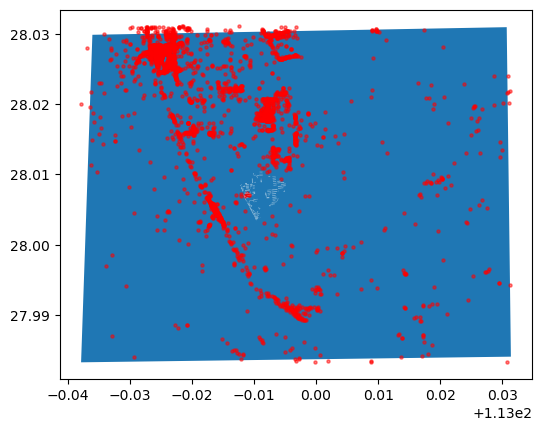

In [34]:
gdf_poi = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.wgs_x, df.wgs_y)).set_crs(epsg=4326)
bud = gpd.read_file(r"D:\College Works\大四下-城市设计\长沙竞赛资料及调研\08矢量数据\建筑.shp").to_crs(epsg=4326)
fig,ax = plt.subplots()
gdf_wgs84.plot(ax=ax)
gdf_poi.plot(ax=ax,color='red',alpha=0.5,markersize=5)
bud.plot(ax=ax,color='w',alpha=0.5)

In [3]:
df = pd.read_csv("poi_results_changsha.csv")
df['大类'] = df['type'].apply(lambda x: x.split(';')[0])
df['大类'].unique()
type_mapping = {
    '购物服务': '商业消费',
    '餐饮服务': '商业消费',
    '金融保险服务': '商业消费',
    '汽车销售': '商业消费',

    '生活服务': '生活服务',

    '公司企业': '办公/产业',

    '交通设施服务': '交通物流',
    '汽车服务': '交通物流',
    '汽车维修': '交通物流',
    '摩托车服务': '交通物流',

    '政府机构及社会团体': '公共服务',
    '科教文化服务': '公共服务',
    '医疗保健服务': '公共服务',

    '体育休闲服务': '休闲娱乐',
    '风景名胜': '休闲娱乐',

    '住宿服务': '旅游住宿',

    '商务住宅': '居住/地产',

    '地名地址信息': '其他',  # 或直接过滤掉
}
df['coarse_type'] = df['大类'].map(type_mapping).fillna('其他')
df.to_csv(r"D:\College Works\大四下-城市设计\长沙竞赛资料及调研\08矢量数据\poi.csv",index=False)

C:\Users\21671\AppData\Local\Temp\ipykernel_39036\513059505.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coarse_type', y='count', data=grouped, ax=ax,legend=False,palette='viridis')
C:\Users\21671\AppData\Local\Temp\ipykernel_39036\513059505.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45)


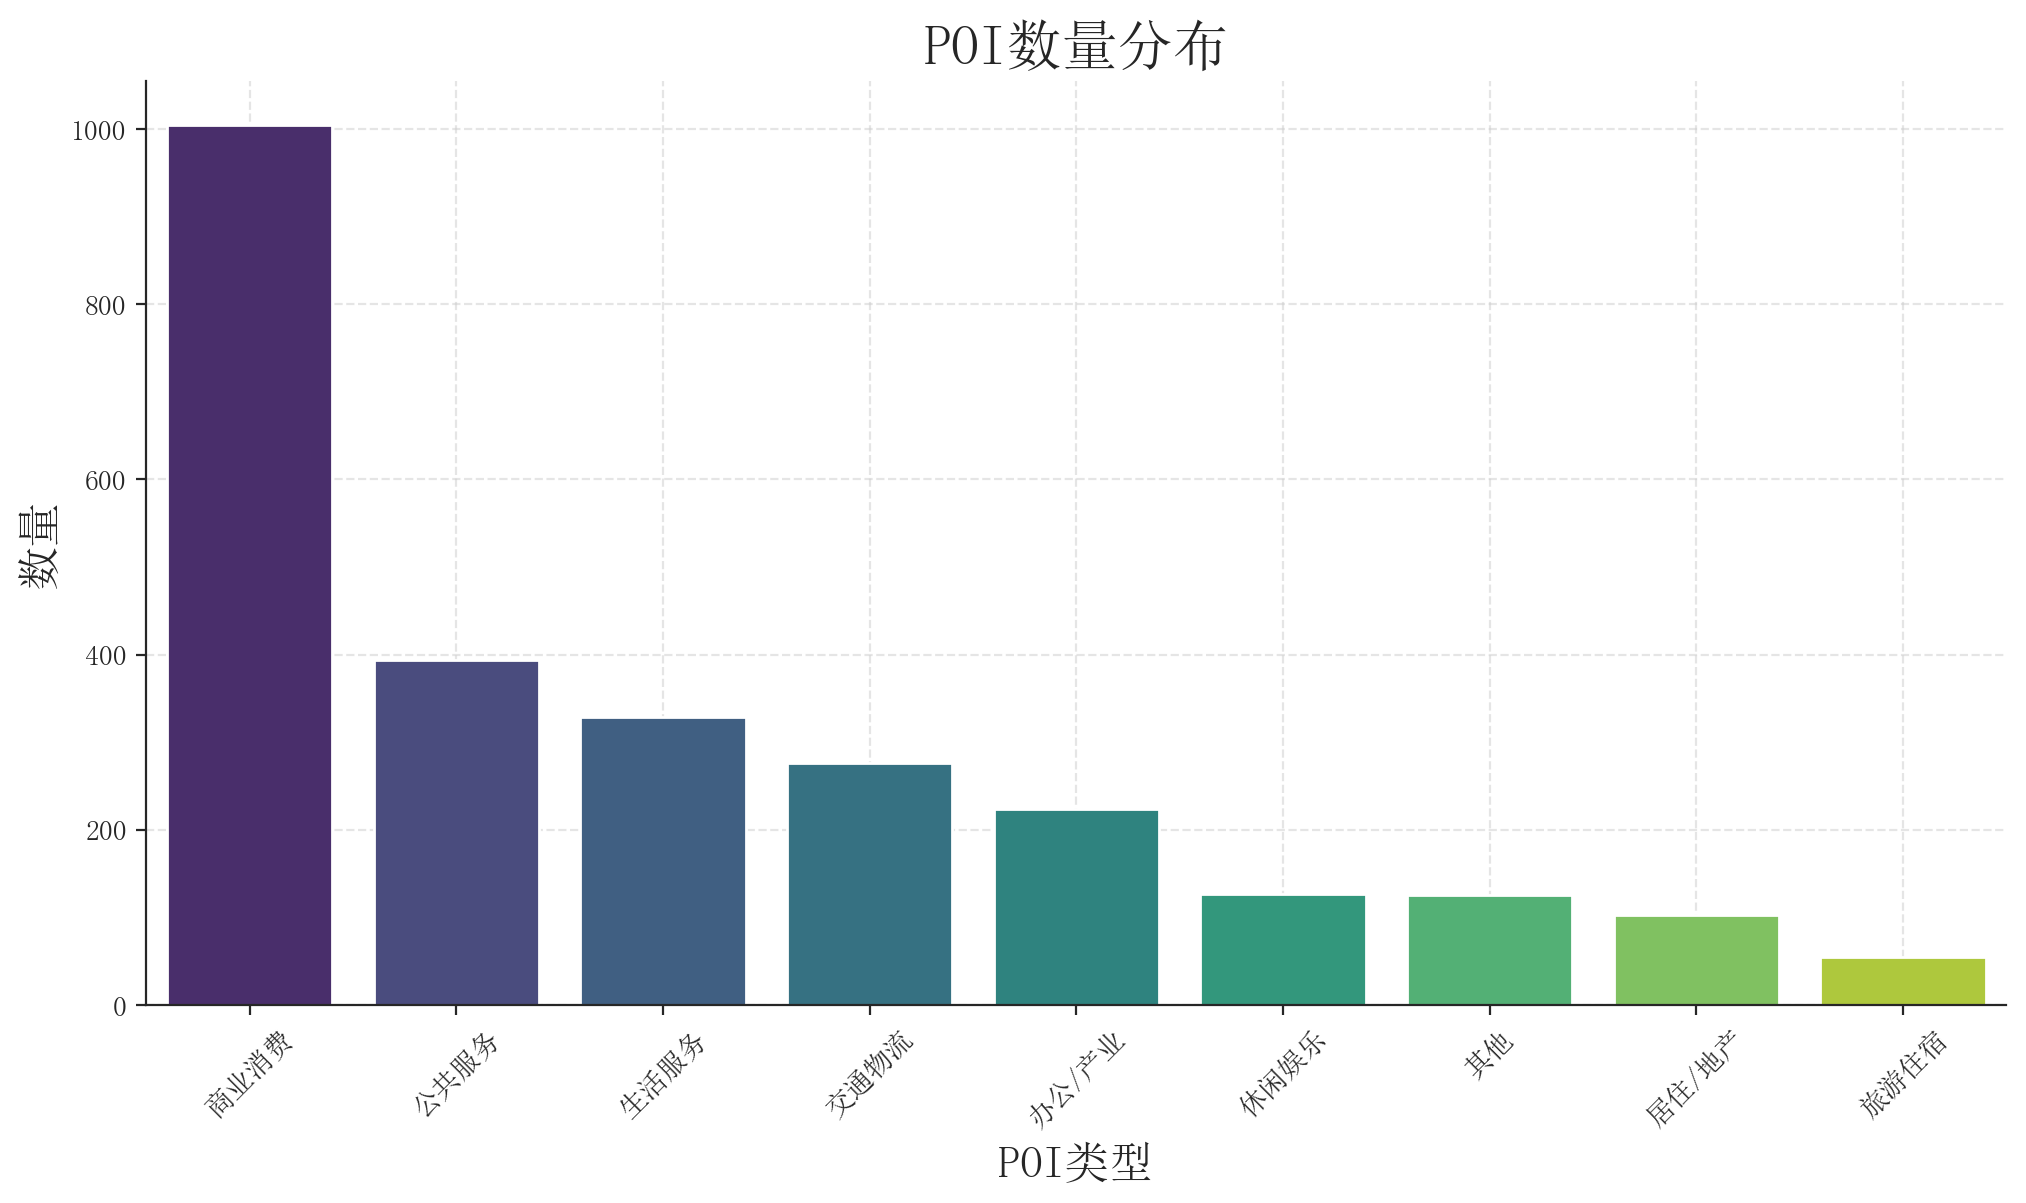

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# 分组统计
grouped = df.groupby('coarse_type').size().to_frame().reset_index().rename(columns={0: 'count'}).sort_values('count', ascending=False)
sns.set_style('ticks')
plt.rcParams['font.sans-serif'] = ['SimSun']
# 绘制饼图
fig, ax = plt.subplots(figsize=(12, 6),dpi=200)  # 可选：设置图形大小
# ax.pie(grouped['count'], labels=grouped['大类'], autopct='%1.1f%%',)
# grouped.plot(kind='bar', x='coarse_type', y='count', ax=ax,color= grouped['count'],cmap='Blues', legend=False)
sns.barplot(x='coarse_type', y='count', data=grouped, ax=ax,legend=False,palette='viridis')
labels = ax.get_xticklabels()
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('POI类型',size=16)
ax.set_ylabel('数量',size=16)
ax.grid(True,linestyle='--',alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('POI数量分布',size=20)
plt.show()

In [ ]:
grouped['coarse_type'] = grouped['大类'].map(type_mapping).fillna('其他')
# # 可选：删除“地名地址信息”这类无意义POI
# df = df[df['type'] != '地名地址信息']

# # 查看浓缩后的分布
# print(df['coarse_type'].value_counts())